## Issue #2: Seven Wears and Done

### Pillar 1 — Price-per-wear vs. real wages

This notebook analyzes the true cost-per-wear of a basic SHEIN straight-leg cotton jean (~$19) against a generic durable mid-range jean (~$60–90), using the widely-cited fast-fashion wear-count average of 7–10 wears (Ellen MacArthur Foundation, 2017) alongside a sliding wear-count scale (5/10/25/50/100).

It also converts the SHEIN jean's price into hours of labor, benchmarked against both the federal minimum wage and BLS average hourly earnings (AHETPI), pulled live from FRED.

**Outputs:**

- `issue02_sliding_scale.png` — cost-per-wear by wear count, SHEIN vs. durable jean  
- `issue02_wage_comparison.png` — hours of labor to afford the jeans, by wage benchmark
- Console-printed hook-stat text (cost-per-wear range) for the carousel's hook slide
APA7 references appended to sources.csv

**Ending thesis:** the math favors the durable jean, but the price gap that makes it a better investment is exactly what puts it out of reach under real financial constraints.

## 1. Setup 

Imports and config for pulling FRED data and building the analysis.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
from pathlib import Path
import requests

FRED_API_KEY = "1760dcc7ad6f191b4e42349df8e3cd1f"
FRED_BASE_URL = "https://api.stlouisfed.org/fred/series/observations"

REPO_ROOT = Path.cwd().parent.parent  # adjust if your notebook lives elsewhere in the repo
PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "issue-02"
CHART_EXPORTS = REPO_ROOT / "content" / "posts" / "issue-02-seven-wears-and-done" / "exports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
CHART_EXPORTS.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Processed data: {PROCESSED_DIR}")
print(f"Chart exports: {CHART_EXPORTS}")

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

Repo root: c:\Users\juvin\OneDrive\Desktop\data-worn-thin
Processed data: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\data\processed\issue-02
Chart exports: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\content\posts\issue-02-seven-wears-and-done\exports


## 2. Load brand palette

In [16]:
PALETTE = {
    "cocoa": "#664E44",
    "dusty": "#B08B7F",
    "peach": "#FFE8D6",
    "cream": "#FAF4E5",
    "sage": "#C7C3B0",
}

plt.rcParams["font.family"] = "Georgia"
plt.rcParams["axes.facecolor"] = PALETTE["cream"]
plt.rcParams["figure.facecolor"] = PALETTE["cream"]
plt.rcParams["text.color"] = PALETTE["cocoa"]
plt.rcParams["axes.edgecolor"] = PALETTE["cocoa"]
plt.rcParams["axes.labelcolor"] = PALETTE["cocoa"]
plt.rcParams["xtick.color"] = PALETTE["cocoa"]
plt.rcParams["ytick.color"] = PALETTE["cocoa"]

## 3. Data loading

This pulls the two wage benchmarks (federal minimum wage, average hourly earnings) from FRED. These will be used to feed the "hours of labor" comparison later.

In [17]:
def fetch_fred_series(series_id, start="2020-01-01"):
    params = {
        "series_id": series_id,
        "api_key": FRED_API_KEY,
        "file_type": "json",
        "observation_start": start,
    }
    resp = requests.get(FRED_BASE_URL, params=params)
    data = resp.json()["observations"]
    df = pd.DataFrame(data)
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df[["date", "value"]]

# federal minimum wage (nominal, not indexed)
fed_min_wage_df = fetch_fred_series("FEDMINNFRWG")
fed_min_wage_current = fed_min_wage_df["value"].iloc[-1]

# average hourly earnings, total private (AHETPI)
ahetpi_df = fetch_fred_series("AHETPI")
ahetpi_current = ahetpi_df["value"].iloc[-1]

print(f"Federal minimum wage (latest): ${fed_min_wage_current:.2f}/hr")
print(f"Average hourly earnings, AHETPI (latest): ${ahetpi_current:.2f}/hr")

Federal minimum wage (latest): $7.25/hr
Average hourly earnings, AHETPI (latest): $32.38/hr


## 4. Manual inputs

Figures that don't come from an API: the SHEIN jean price, the generic durable-jean price range, and the wear-count assumptions (Ellen MacArthur Foundation average, plus the sliding scale). These need dated screenshots/citations before publishing, since retail prices drift.


In [18]:
# SHEIN Women's Light Blue Straight Leg Jeans, Washed Effect, 90% Cotton
# Source: SHEIN AU, checked 2026-07-31, rated 4.71 (1000+ reviews), 1.3k+ sold
# Listed price: AU$29.95 -> converted at 1 AUD = 0.7026 USD (2026-07-31 rate)
shein_jean_price = 21.04

# Durable/mid-range jean price range (generic in published content, per Issue 2 scope decision)
# Internal reference point: a well-known heritage denim brand's straight-leg jean, AU$159.95
# -> converted to USD $112.38 at 1 AUD = 0.7026 USD (2026-07-31 rate)
# Range widened slightly around this reference to keep the comparison generic rather than
# pinned to one specific product/price
durable_jean_low = 100.00
durable_jean_high = 160.00
durable_jean_mid = (durable_jean_low + durable_jean_high) / 2

fast_fashion_wears_low = 7
fast_fashion_wears_high = 10
wear_scale = [5, 10, 25, 50, 100]

## 5. Analysis

Computes the headline cost-per-wear range (as a text stat for the hook slide, not a standalone chart), the hours-of-labor figures for both wage benchmarks, and the sliding-scale dataframe that powers the anchor chart.

In [19]:
def cost_per_wear(price, wears):
    return price / wears

# Headline cost-per-wear range — SHEIN jean, fixed at the fast-fashion average
shein_cpw_low = cost_per_wear(shein_jean_price, fast_fashion_wears_high)
shein_cpw_high = cost_per_wear(shein_jean_price, fast_fashion_wears_low)

print(f"HOOK STAT TEXT: Cost per wear ranges from ${shein_cpw_low:.2f} to ${shein_cpw_high:.2f}")

hours_min_wage = shein_jean_price / fed_min_wage_current
hours_avg_wage = shein_jean_price / ahetpi_current
print(f"Hours at federal minimum wage: {hours_min_wage:.2f}")
print(f"Hours at average hourly earnings: {hours_avg_wage:.2f}")

# CORRECTED sliding scale: durable jean's wear-count varies, SHEIN jean's cost-per-wear
# is fixed at its real-world average (7-10 wears), since that's the actual disposal pattern
durable_wear_scale = [10, 25, 50, 75, 100, 150, 200]

sliding_scale_df = pd.DataFrame({
    "durable_wears": durable_wear_scale,
    "durable_cpw": [cost_per_wear(durable_jean_mid, w) for w in durable_wear_scale],
})
sliding_scale_df["shein_cpw_reference"] = shein_cpw_high  # flat reference line at 7-wear cost
sliding_scale_df["durable_wins"] = sliding_scale_df["durable_cpw"] < sliding_scale_df["shein_cpw_reference"]

# Breakeven point: how many wears the durable jean needs to match the SHEIN cost-per-wear
breakeven_wears = durable_jean_mid / shein_cpw_high
print(f"\nBreakeven: the durable jean needs {breakeven_wears:.0f} wears to match the SHEIN jean's cost-per-wear.")

sliding_scale_df

HOOK STAT TEXT: Cost per wear ranges from $2.10 to $3.01
Hours at federal minimum wage: 2.90
Hours at average hourly earnings: 0.65

Breakeven: the durable jean needs 43 wears to match the SHEIN jean's cost-per-wear.


,durable_wears,durable_cpw,shein_cpw_reference,durable_wins
0,10,13.00,3.01,False
1,25,5.20,3.01,False
2,50,2.60,3.01,True
3,75,1.73,3.01,True
4,100,1.30,3.01,True
5,150,0.87,3.01,True
6,200,0.65,3.01,True


## 6. Charting

###  6.1 Sliding scale comparison

Chart 1 (anchor visual): the sliding-scale line chart. Shows where the durable jean's cost-per-wear drops below the SHEIN jean's, making the "math favors durable, but only if you keep it long enough" argument visible without asserting one disputed number. With the updated $130 midpoint, expect this crossover to land later on the x-axis than earlier drafts.

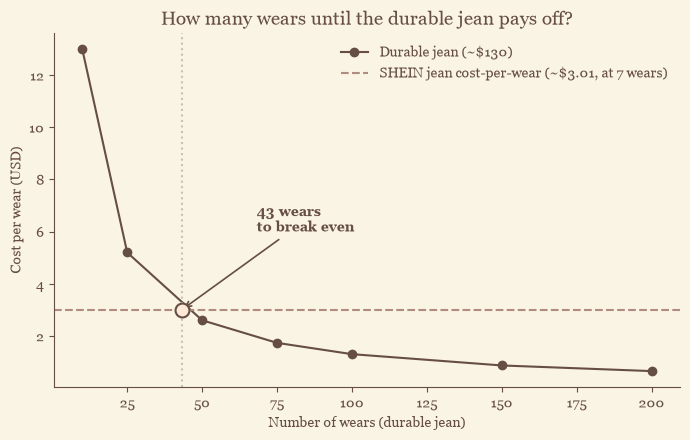

In [31]:
fig1, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sliding_scale_df["durable_wears"], sliding_scale_df["durable_cpw"],
        marker="o", color=PALETTE["cocoa"], label=f"Durable jean (~${durable_jean_mid:.0f})")
ax.axhline(y=shein_cpw_high, color=PALETTE["dusty"], linestyle="--",
           label=f"SHEIN jean cost-per-wear (~${shein_cpw_high:.2f}, at 7 wears)")

# Mark the breakeven point explicitly
ax.axvline(x=breakeven_wears, color=PALETTE["sage"], linestyle=":", linewidth=1.5)
ax.plot(breakeven_wears, shein_cpw_high, marker="o", markersize=10,
        markerfacecolor=PALETTE["peach"], markeredgecolor=PALETTE["cocoa"], markeredgewidth=1.5, zorder=5)
ax.annotate(
    f"{breakeven_wears:.0f} wears\nto break even",
    xy=(breakeven_wears, shein_cpw_high),
    xytext=(breakeven_wears + 25, shein_cpw_high + 3),
    fontsize=10, color=PALETTE["cocoa"], fontweight="bold",
    ha="left",
    arrowprops=dict(arrowstyle="->", color=PALETTE["cocoa"], lw=1.2)
)

ax.set_xlabel("Number of wears (durable jean)")
ax.set_ylabel("Cost per wear (USD)")
ax.set_title("How many wears until the durable jean pays off?", fontsize=14, color=PALETTE["cocoa"])
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 6.2 Wage comparison

Chart 2 : Hours of labor to afford both the affordable and durable jeans, at both wage benchmarks side by side. Pairs with Chart 1's "cost per wear" half to cover both sides of the piece: what it costs, and who it costs the most.



Durable jean hours at minimum wage: 17.93
Durable jean hours at average wage: 4.01


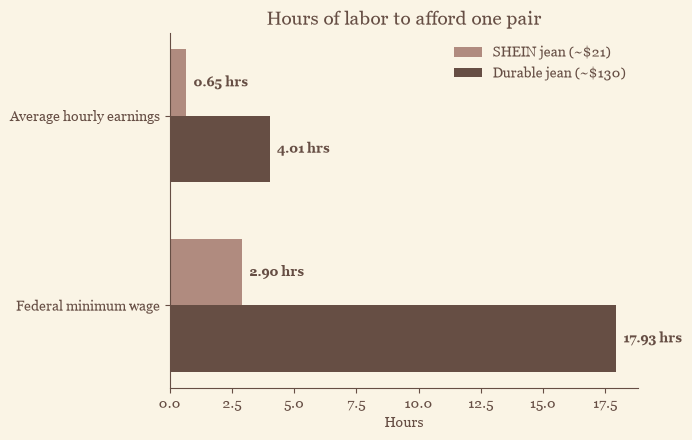

In [42]:
# Durable jean hours calculations, added alongside existing SHEIN figures
hours_min_wage_durable = durable_jean_mid / fed_min_wage_current
hours_avg_wage_durable = durable_jean_mid / ahetpi_current

print(f"Durable jean hours at minimum wage: {hours_min_wage_durable:.2f}")
print(f"Durable jean hours at average wage: {hours_avg_wage_durable:.2f}")

fig2, ax = plt.subplots(figsize=(7, 4.5))

labels = ["Federal minimum wage", "Average hourly earnings"]
shein_hours = [hours_min_wage, hours_avg_wage]
durable_hours = [hours_min_wage_durable, hours_avg_wage_durable]

x = range(len(labels))
width = 0.35

bars1 = ax.barh([i + width/2 for i in x], shein_hours, height=width,
                color=PALETTE["dusty"], label=f"SHEIN jean (~${shein_jean_price:.0f})")
bars2 = ax.barh([i - width/2 for i in x], durable_hours, height=width,
                color=PALETTE["cocoa"], label=f"Durable jean (~${durable_jean_mid:.0f})")

for bars in [bars1, bars2]:
    for bar in bars:
        width_val = bar.get_width()
        ax.text(width_val + 0.3, bar.get_y() + bar.get_height()/2, f"{width_val:.2f} hrs",
                va="center", color=PALETTE["cocoa"], fontweight="bold", fontsize=9)

ax.set_yticks(list(x))
ax.set_yticklabels(labels)
ax.set_title("Hours of labor to afford one pair", fontsize=14, color=PALETTE["cocoa"])
ax.set_xlabel("Hours")
ax.legend(frameon=False, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Findings

Plain-language summary of the four key takeaways, pulled straight from the computed values above. Refer to this when making the first draft for the "break it down" and "the take" slide copy.

In [43]:
print("KEY FINDINGS")
print("-" * 40)
print(f"1. SHEIN jean cost-per-wear: ${shein_cpw_low:.2f} to ${shein_cpw_high:.2f}, based on the typical 7 to 10 fast-fashion wear-count (Ellen MacArthur Foundation, 2017).")
print(f"2. A well-made durable pair can realistically handle 100 to 200 wears, well past the 43-wear breakeven point.")
print(f"3. Buying the SHEIN pair costs {hours_min_wage:.2f} hours of labor at federal minimum wage, versus {hours_avg_wage:.2f} hours at average earnings.")
print(f"4. The durable pair costs far more time upfront: {hours_min_wage_durable:.2f} hours at minimum wage, versus {hours_avg_wage_durable:.2f} hours at average earnings.")
print(f"5. The durable jean (~${durable_jean_mid:.0f}) needs {breakeven_wears:.0f} wears to match the SHEIN jean's cost-per-wear, after that, every additional wear makes it the cheaper option.")
print("6. The math favors the durable jean well within a realistic lifespan, but the time and money required upfront are exactly what make that choice inaccessible under real financial constraints.")

KEY FINDINGS
----------------------------------------
1. SHEIN jean cost-per-wear: $2.10 to $3.01, based on the typical 7 to 10 fast-fashion wear-count (Ellen MacArthur Foundation, 2017).
2. A well-made durable pair can realistically handle 100 to 200 wears, well past the 43-wear breakeven point.
3. Buying the SHEIN pair costs 2.90 hours of labor at federal minimum wage, versus 0.65 hours at average earnings.
4. The durable pair costs far more time upfront: 17.93 hours at minimum wage, versus 4.01 hours at average earnings.
5. The durable jean (~$130) needs 43 wears to match the SHEIN jean's cost-per-wear, after that, every additional wear makes it the cheaper option.
6. The math favors the durable jean well within a realistic lifespan, but the time and money required upfront are exactly what make that choice inaccessible under real financial constraints.


## 8. Save outputs

In [44]:
# Save processed data
out_csv = PROCESSED_DIR / "cost_per_wear_indexed.csv"
sliding_scale_df.to_csv(out_csv, index=False)
print(f"Processed data saved to: {out_csv}")

# Save Chart 1: sliding scale / breakeven
out_png_1 = POST_EXPORTS / "chart1_cost_per_wear_breakeven.png"
fig1.savefig(out_png_1, facecolor=fig1.get_facecolor(), bbox_inches="tight")
print(f"Chart saved to: {out_png_1}")

# Save Chart 2: wage comparison
out_png_2 = POST_EXPORTS / "chart2_wage_comparison.png"
fig2.savefig(out_png_2, facecolor=fig2.get_facecolor(), bbox_inches="tight")
print(f"Chart saved to: {out_png_2}")

Processed data saved to: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\data\processed\issue-02\cost_per_wear_indexed.csv
Chart saved to: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\content\posts\issue-02-seven-wears-and-done\exports\chart1_cost_per_wear_breakeven.png
Chart saved to: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\content\posts\issue-02-seven-wears-and-done\exports\chart2_wage_comparison.png
